In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import stppsf
from stppsf.math_module import xp, xcipy, ensure_np_array
import stppsf.utils as utils
import stppsf.esc_fresnel as esc
import stppsf.esc_optics as esc_optics
from stppsf.imshows import imshow1, imshow2, imshow3

import lina.utils
import lina.efc as efc


In [ ]:
wfe_path = Path('/npool/nvme/kianmilani/esc-wfe-maps')
inter = poppy.poppy_core.PlaneType.intermediate

wfes = {
    'm1':poppy.FITSOpticalElement(name='m1_wfe', opd=str(wfe_path/'m1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm2':poppy.FITSOpticalElement(name='m2_wfe', opd=str(wfe_path/'m2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm3':poppy.FITSOpticalElement(name='m3_wfe', opd=str(wfe_path/'m3_subap.fits'), opdunits='nanometers', planetype=inter), 
    'm4':poppy.FITSOpticalElement(name='m4_wfe', opd=str(wfe_path/'m4_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap1':poppy.FITSOpticalElement(name='oap1_wfe', opd=str(wfe_path/'oap1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fm1':poppy.FITSOpticalElement(name='fm1_wfe', opd=str(wfe_path/'fm1_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap2':poppy.FITSOpticalElement(name='oap2_wfe', opd=str(wfe_path/'oap2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap3':poppy.FITSOpticalElement(name='oap3_wfe', opd=str(wfe_path/'oap3_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fsm':poppy.FITSOpticalElement(name='fsm_wfe', opd=str(wfe_path/'fsm_subap.fits'), opdunits='nanometers', planetype=inter), 
    'fm2':poppy.FITSOpticalElement(name='fm2_wfe', opd=str(wfe_path/'fm2_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap4':poppy.FITSOpticalElement(name='oap4_wfe', opd=str(wfe_path/'oap4_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap5':poppy.FITSOpticalElement(name='oap5_wfe', opd=str(wfe_path/'oap5_subap.fits'), opdunits='nanometers', planetype=inter), 
    'input_lp':poppy.FITSOpticalElement(name='input_lp_wfe', opd=str(wfe_path/'input_lp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'input_qwp':poppy.FITSOpticalElement(name='input_qwp_wfe', opd=str(wfe_path/'input_qwp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap6':poppy.FITSOpticalElement(name='oap6_wfe', opd=str(wfe_path/'oap6_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap7':poppy.FITSOpticalElement(name='oap7_wfe', opd=str(wfe_path/'oap7_subap.fits'), opdunits='nanometers', planetype=inter), 
    # 'oap8_locam':poppy.FITSOpticalElement(name='oap8_wfe', opd=str(wfe_path/'oap8_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap9':poppy.FITSOpticalElement(name='oap9_wfe', opd=str(wfe_path/'oap9_subap.fits'), opdunits='nanometers', planetype=inter), 
    'collimator':poppy.FITSOpticalElement(name='collimator_wfe', opd=str(wfe_path/'collimator_subap.fits'), opdunits='nanometers', planetype=inter), 
    'filter':poppy.FITSOpticalElement(name='filter_wfe', opd=str(wfe_path/'filter_subap.fits'), opdunits='nanometers', planetype=inter), 
    'output_qwp':poppy.FITSOpticalElement(name='output_qwp_wfe', opd=str(wfe_path/'output_qwp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'output_lp':poppy.FITSOpticalElement(name='output_lp_wfe', opd=str(wfe_path/'output_lp_subap.fits'), opdunits='nanometers', planetype=inter), 
    'oap10':poppy.FITSOpticalElement(name='oap10_wfe', opd=str(wfe_path/'oap10_subap.fits'), opdunits='nanometers', planetype=inter), 
}



In [ ]:
reload(esc)
ref_dir = '/npool/nvme/kvangorkom/reflectivity_maps_2024_09_15/'
sim_dir = '/npool/nvme/ramyaanche/esc_wfe_sims/6nm_surfPSD/'
wfe_optic = 12
opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    'oap7': wfe_optic*u.nm, 
    # 'oap8_locam': 6*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=sim_dir+f'{optic}_subap.fits' , opdunits='nanometers',
        transmission=ref_dir+f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

In [57]:
M.wfes[optic].shape

(3072, 3072)

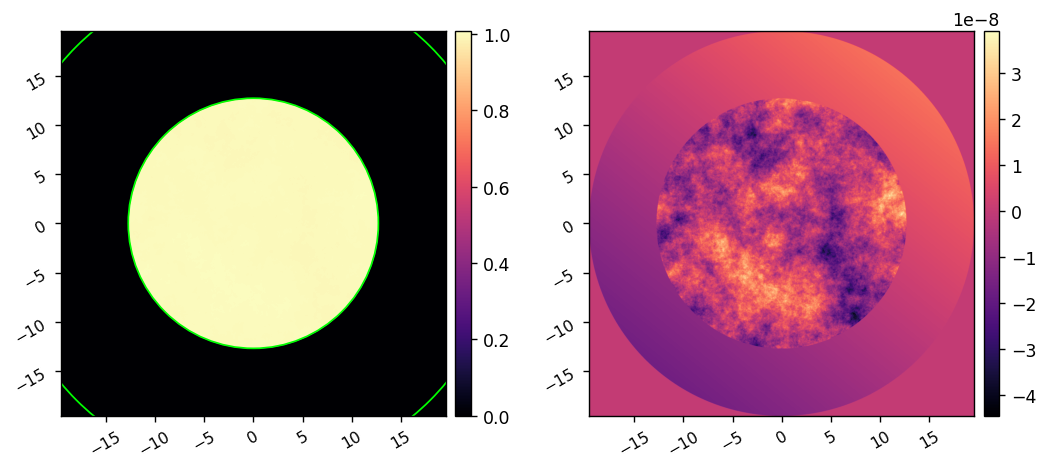

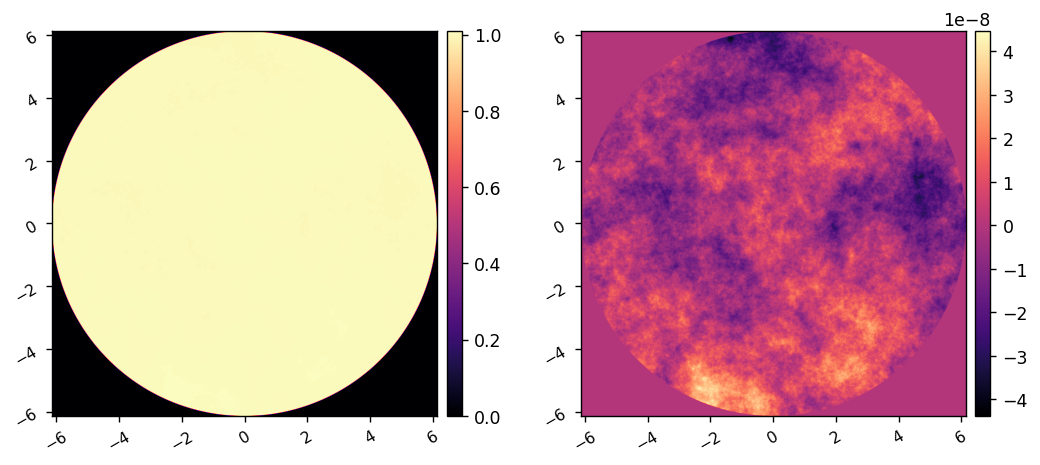

In [8]:
optic = 'oap2'
# optic = 'input_lp'
imshow2(M.wfes[optic].amplitude, M.wfes[optic].opd, pxscl=M.wfes[optic].pixelscale.to(u.mm/u.pix), 
        patches1=[Circle((0,0), 25.4/2, fill=False, color='lime'),
                  Circle((0,0), 25.4, fill=False, color='lime')],
        )
optic = 'oap10'
imshow2(M.wfes[optic].amplitude, M.wfes[optic].opd, pxscl=M.wfes[optic].pixelscale.to(u.mm/u.pix), 
        patches1=[Circle((0,0), 25.4/2, fill=False, color='lime'),
                  Circle((0,0), 25.4, fill=False, color='lime')],
        )

In [4]:
reload(esc)
M = esc.single()
M.wfes = wfes

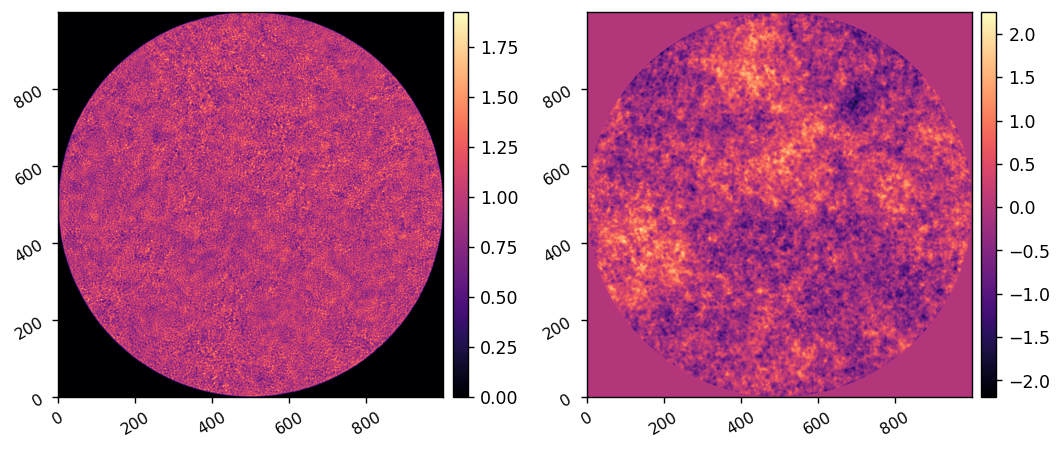

In [137]:
M.return_lyot = True
M.npix = 1000
M.oversample = 2.048
M.use_vortex = False
lyot_wfe = utils.pad_or_crop(M.calc_wf(), M.npix)
lyot_amp = xp.abs(lyot_wfe)* M.apmask
lyot_phs = xp.angle(lyot_wfe)* M.apmask
lyot_wfe = lyot_amp * xp.exp(1j*lyot_phs)
imshow2(xp.abs(lyot_wfe), xp.angle(lyot_wfe))

M.return_lyot = False
M.npix = 1000
M.oversample = 4.096
M.use_vortex = True

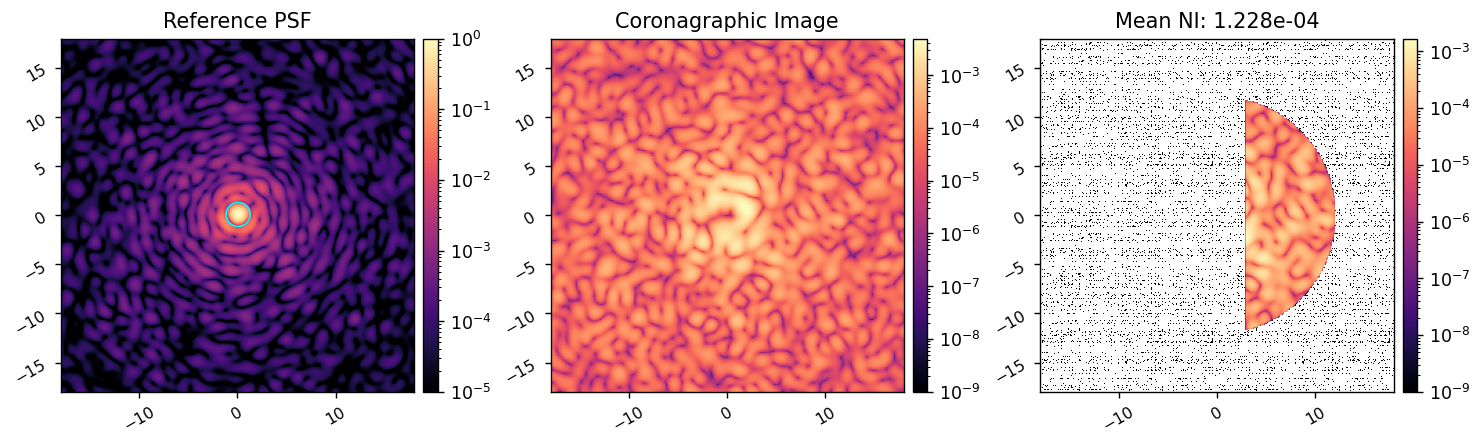

In [135]:
reload(esc)
poppy_log.disabled = True

M = esc.single()
M.wfes = wfes
M.lyot_corr = -0.45*u.mm

ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)
M.use_vortex = True
ref_coro_im = M.snap()

iwa = 3
owa = 12
control_mask = lina.utils.create_annular_focal_plane_mask(M.npsf, M.psf_pixelscale_lamD, iwa, owa, edge=iwa)
mean_ni = xp.mean(ref_coro_im[control_mask])

psf_center = (M.psf_pixelscale_lamD/2, M.psf_pixelscale_lamD/2)
imshow3(ref_psf/M.Imax_ref, ref_coro_im, control_mask*ref_coro_im, 
        'Reference PSF', 'Coronagraphic Image', f'Mean NI: {mean_ni:.3e}', 
        lognorm=True, vmin1=1e-5, vmin2=1e-9, vmin3=1e-9, 
        npix=M.npsf, pxscl=M.psf_pixelscale_lamD, 
        patches1=[Circle(psf_center, 1.22, fill=False, color='cyan')])

In [84]:
poppy_log.disabled = False

im = M.snap()

INFO:poppy:Initialized OpticalSystem: ESC to FPM
INFO:poppy:Added optic: Entrance Pupil (subaperture) after separation: 0.00e+00 m 
INFO:poppy:Added optic: Dummy Pupil OPD after separation: 0.00e+00 m 
INFO:poppy:Added optic: m1 after separation: 0.00e+00 m 
INFO:poppy:Added optic: m1_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: m2 after separation: 7.50e+03 mm 
INFO:poppy:Added optic: m2_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: m3 after separation: 7.44e+03 mm 
INFO:poppy:Added optic: m3_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: m4 (pupil) after separation: 1.05e+03 mm 
INFO:poppy:Added optic: m4_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: WCC_FP after separation: 1.27e+03 mm 
INFO:poppy:Added optic: oap1 after separation: 5.11e+02 mm 
INFO:poppy:Added optic: oap1_wfe after separation: 0.00e+00 m 
INFO:poppy:Added optic: fm1 after separation: 1.91e+02 mm 
INFO:poppy:Added optic: fm1_wfe after separation: 0.00e+00 m 
INFO:popp

In [90]:
reload(lina)
poke_amp = 1e-9
poke_modes = lina.utils.create_all_poke_modes(M.dm_mask)



Calculating Jacobian: 
	Calculated response for mode 952/952. Elapsed time=606.213 sec.
Jacobian built in 606.213 sec


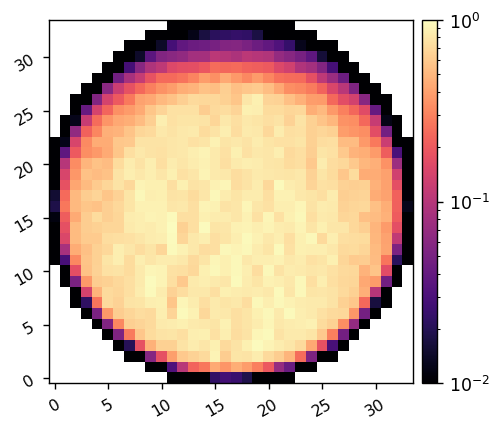

In [91]:
reload(lina.efc)

jac, response_cube = lina.efc.calibrate(M,
                                        poke_modes,
                                        #  poke_modes[800:951], 
                                        poke_amp,
                                        control_mask, 
                                        plot=True,
                                        return_all=True
                                        )

In [19]:
lina.utils.save_fits(f'../data/{today}_esc_fresnel_efc_cube.fits', response_cube)

Saved data to:  ../data/20240930_esc_fresnel_efc_cube.fits


In [92]:
M.zero_dm()
all_ims = []
all_efs = []
all_commands = []



Beginning closed-loop EFC.
	Closed-loop iteration 25 / 27
Using model to compute electric field


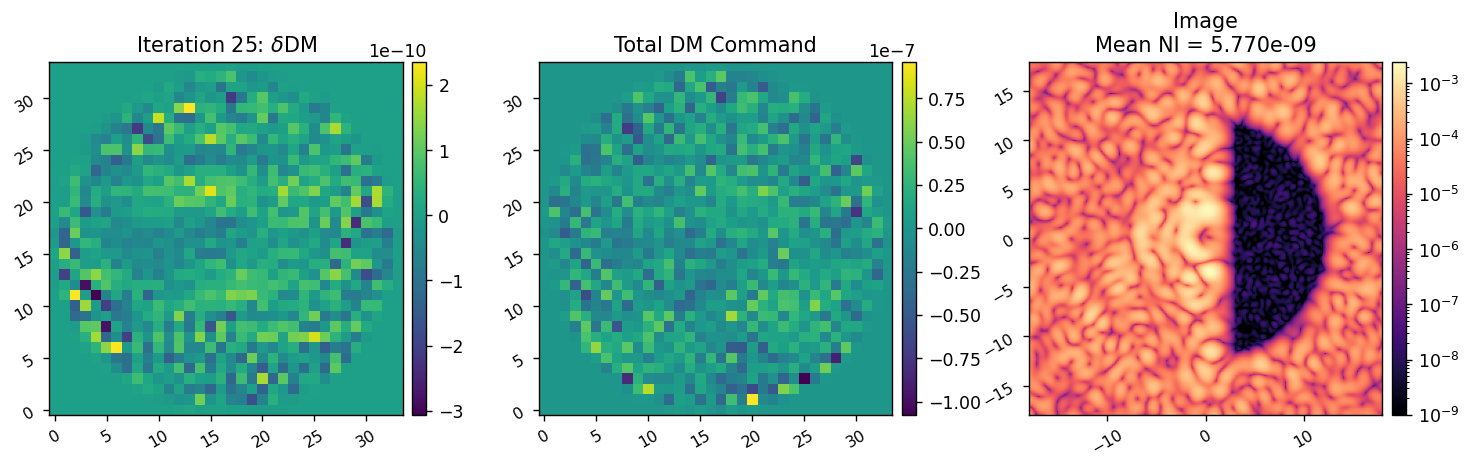

	Closed-loop iteration 26 / 27
Using model to compute electric field


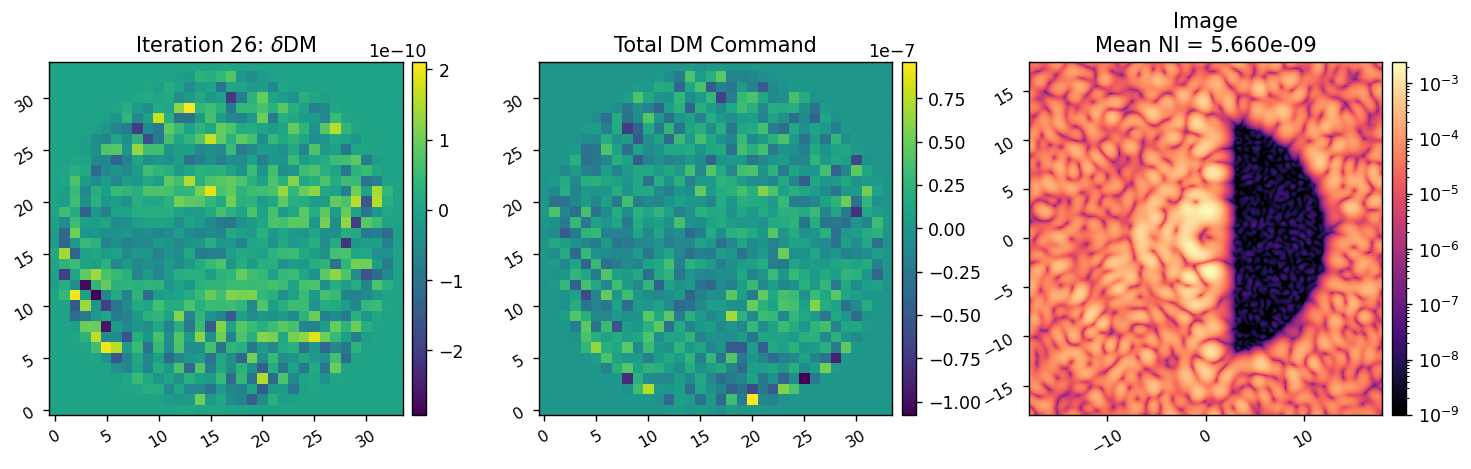

	Closed-loop iteration 27 / 27
Using model to compute electric field


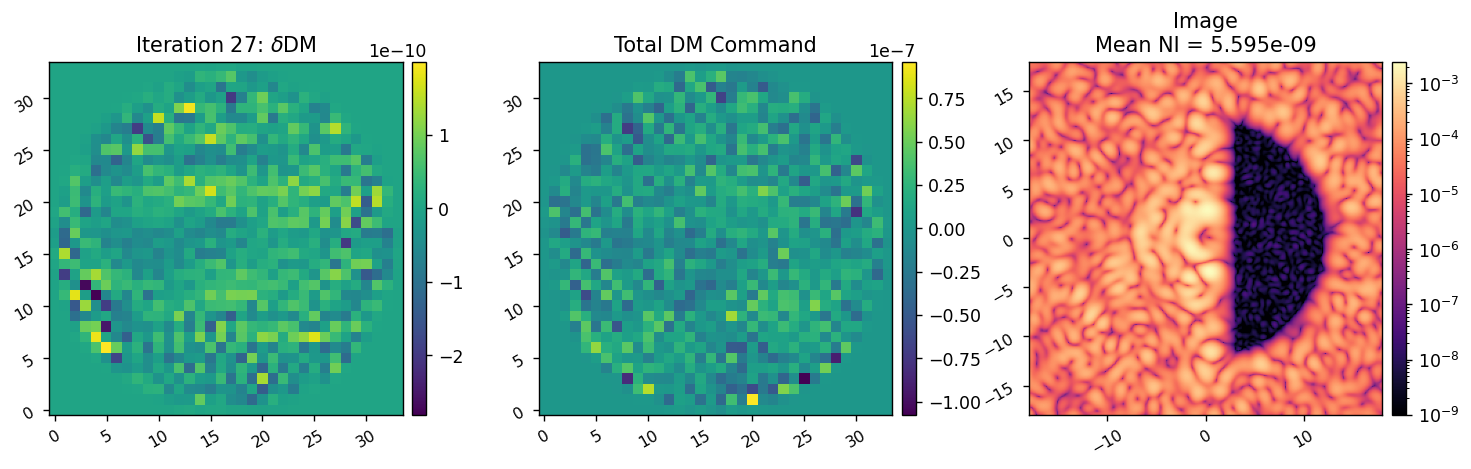

EFC completed in 4.241 sec.


In [101]:
reload(lina.efc)

control_matrix = lina.utils.beta_reg(jac, -2.5)
# control_matrix = lina.utils.beta_reg(jac, -5)

images, fields, dm_commands = lina.efc.run(M,
                                            control_matrix,
                                            poke_modes,
                                            control_mask, 
                                            # est_fun=est_fun,
                                            # est_params=est_params,
                                            loop_gain=0.5, 
                                            leakage=0.0,
                                            iterations=3, 
                                            plot_all=True, 
                                            plot_sms=False,
                                            plot_radial_contrast=False,
                                            all_ims=all_ims,
                                            all_efs=all_efs,
                                            all_commands=all_commands,
                                            )

Calculating Jacobian: 
	Calculated response for mode 952/952. Elapsed time=608.433 sec.
Jacobian built in 608.433 sec


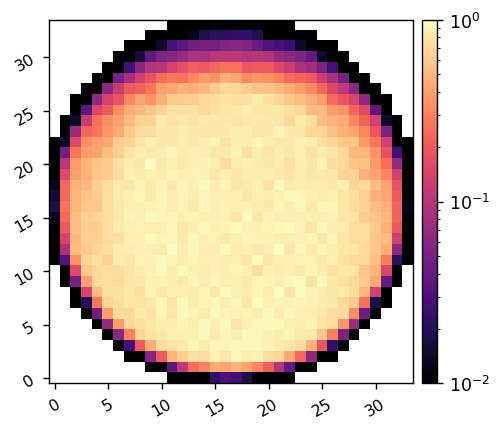

In [102]:
reload(lina.efc)
jac_2, response_cube_2 = lina.efc.calibrate(M,
                                            poke_modes,
                                            #  poke_modes[800:951], 
                                            poke_amp,
                                            control_mask, 
                                            plot=True,
                                            return_all=True
                                            )

In [29]:
lina.utils.save_fits(f'../data/{today}_esc_fresnel_efc_cube_2.fits', response_cube)

Saved data to:  ../data/20240930_esc_fresnel_efc_cube_2.fits


Beginning closed-loop EFC.
	Closed-loop iteration 55 / 57
Using model to compute electric field


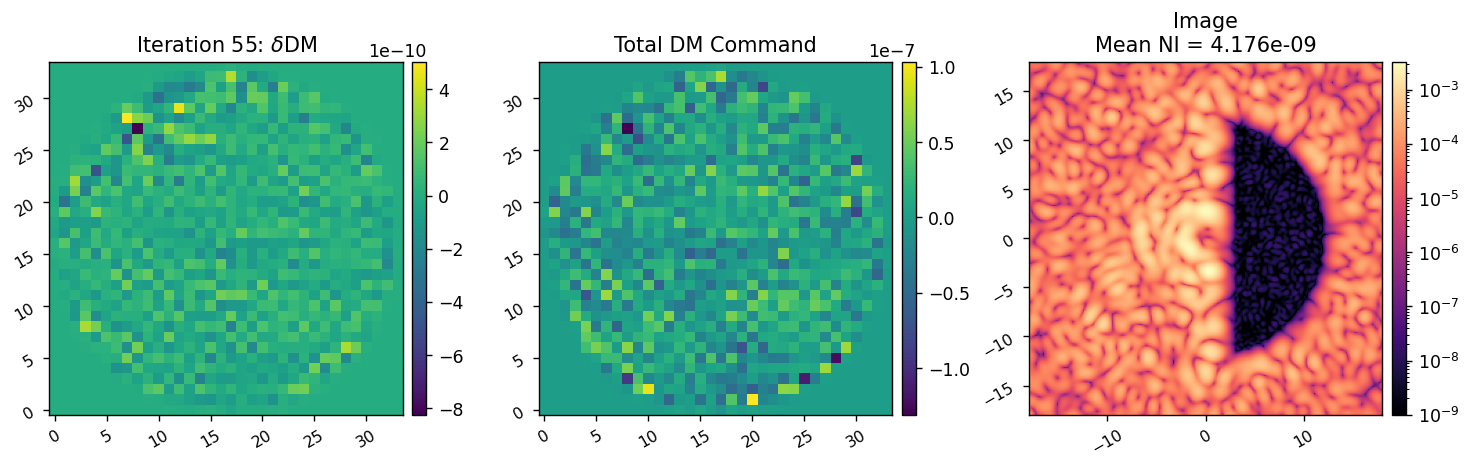

	Closed-loop iteration 56 / 57
Using model to compute electric field


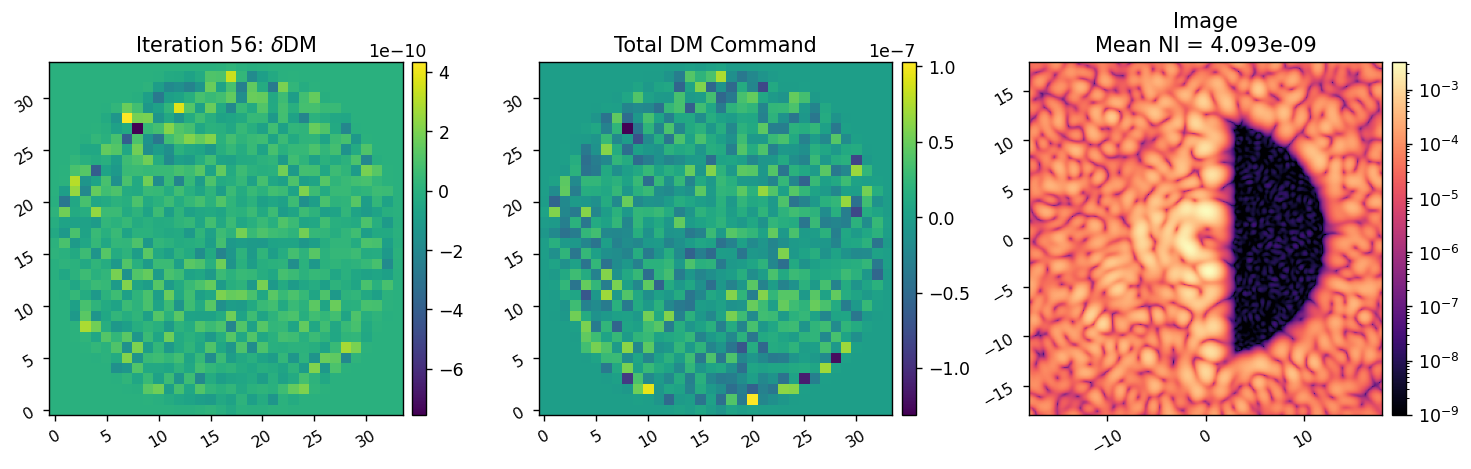

	Closed-loop iteration 57 / 57
Using model to compute electric field


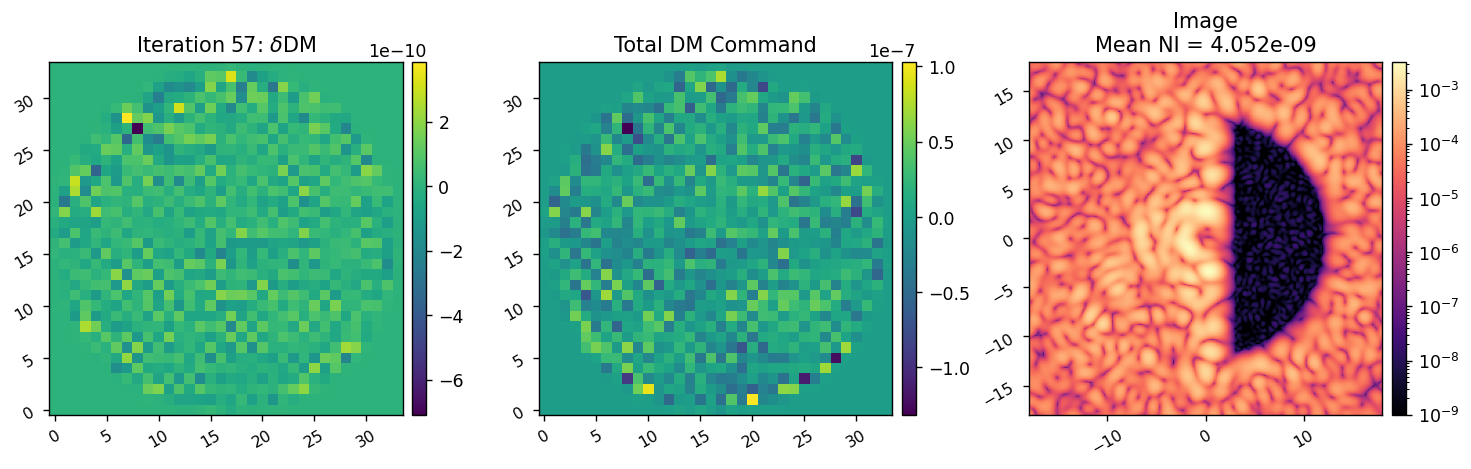

EFC completed in 3.862 sec.


In [112]:
reload(lina.efc)

control_matrix = lina.utils.beta_reg(jac_2, -1.5)
control_matrix = lina.utils.beta_reg(jac_2, -2.5)
control_matrix = lina.utils.beta_reg(jac_2, -3.5)
# control_matrix = lina.utils.beta_reg(jac_2, -5)

images, fields, dm_commands = lina.efc.run(M,
                                            control_matrix,
                                            poke_modes,
                                            control_mask, 
                                            # est_fun=est_fun,
                                            # est_params=est_params,
                                            loop_gain=0.5, 
                                            leakage=0.0,
                                            iterations=3, 
                                            plot_all=True, 
                                            plot_sms=False,
                                            plot_radial_contrast=False,
                                            all_ims=all_ims,
                                            all_efs=all_efs,
                                            all_commands=all_commands,
                                            )

Calculating Jacobian: 
	Calculated response for mode 952/952. Elapsed time=607.039 sec.
Jacobian built in 607.039 sec


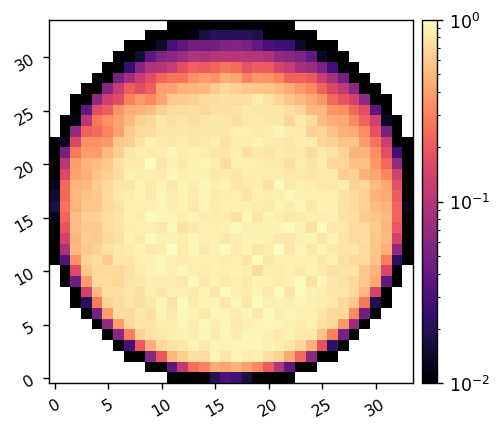

In [113]:
reload(lina.efc)
jac_3, response_cube_3 = lina.efc.calibrate(M,
                                            poke_modes,
                                            #  poke_modes[800:951], 
                                            poke_amp,
                                            control_mask, 
                                            plot=True,
                                            return_all=True,
                                            )

Beginning closed-loop EFC.
	Closed-loop iteration 82 / 84
Using model to compute electric field


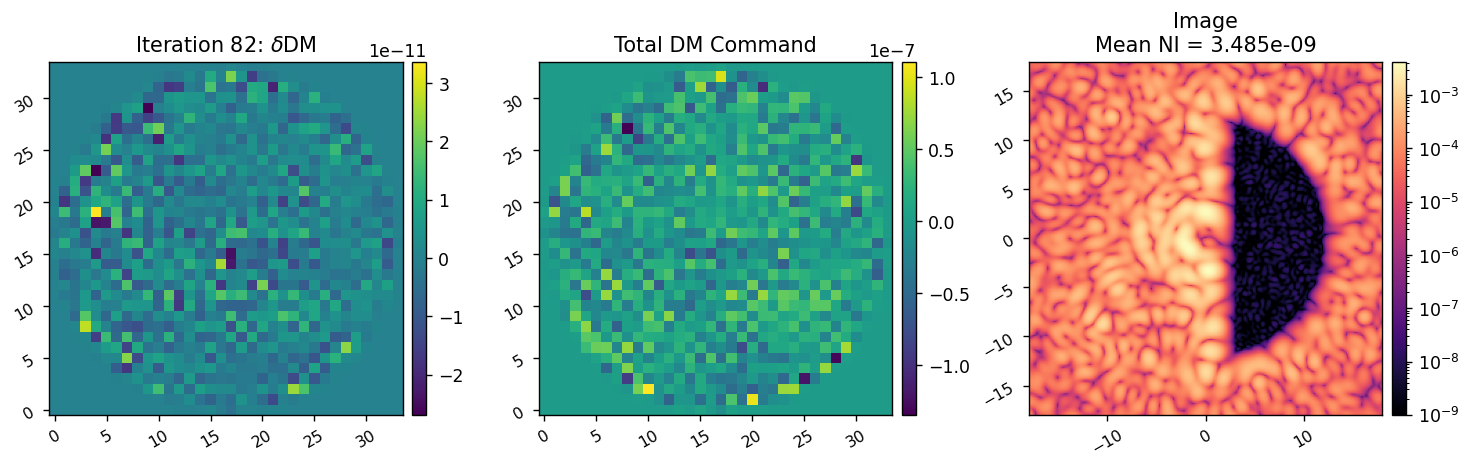

	Closed-loop iteration 83 / 84
Using model to compute electric field


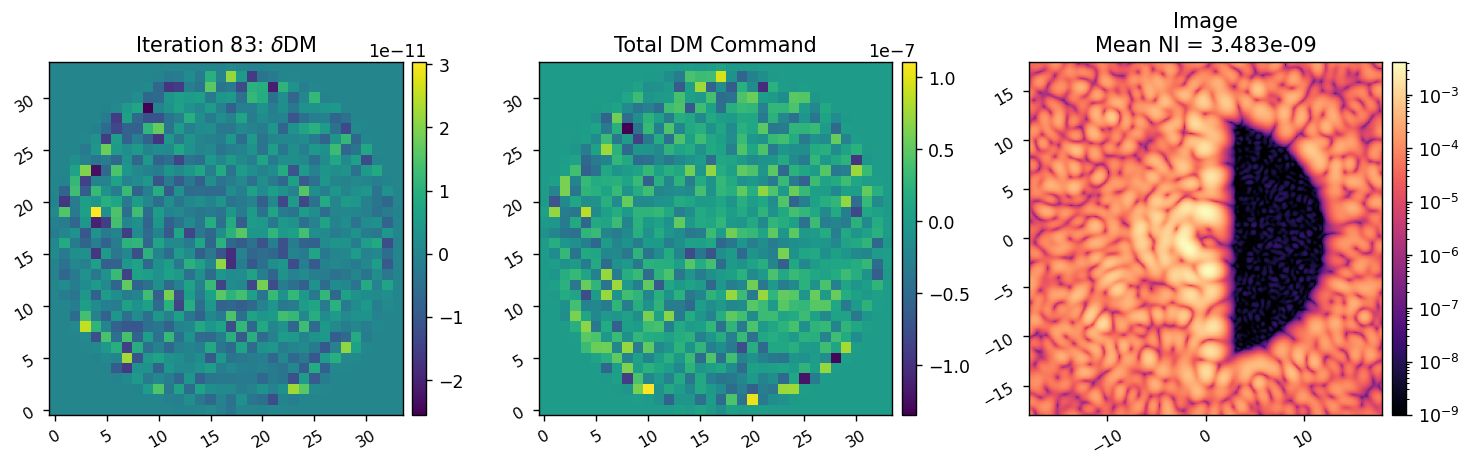

	Closed-loop iteration 84 / 84
Using model to compute electric field


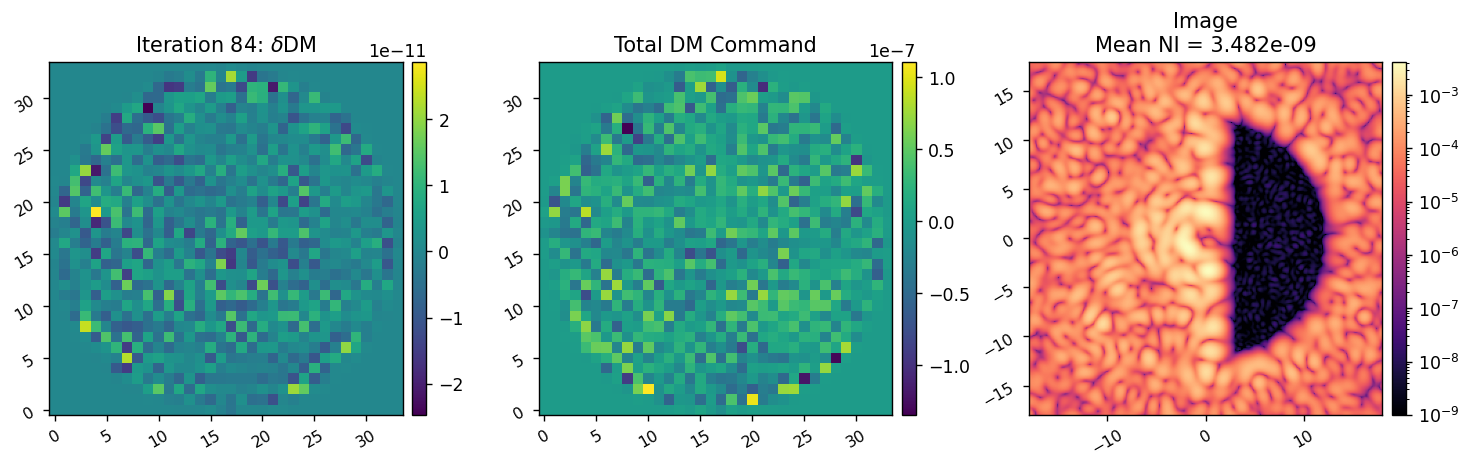

EFC completed in 3.926 sec.


In [122]:
reload(lina.efc)

control_matrix = lina.utils.beta_reg(jac_3, -1.5)
control_matrix = lina.utils.beta_reg(jac_3, -2.5)
# control_matrix = lina.utils.beta_reg(jac_3, -3.5)
# control_matrix = lina.utils.beta_reg(jac_3, -5)

images, fields, dm_commands = lina.efc.run(M,
                                            control_matrix,
                                            poke_modes,
                                            control_mask, 
                                            # est_fun=est_fun,
                                            # est_params=est_params,
                                            loop_gain=0.5, 
                                            leakage=0.0,
                                            iterations=3, 
                                            plot_all=True, 
                                            plot_sms=False,
                                            plot_radial_contrast=False,
                                            all_ims=all_ims,
                                            all_efs=all_efs,
                                            all_commands=all_commands,
                                            )

In [125]:
Nwaves = 5
bw = 0.05
waves = np.linspace(M.wavelength_c * (1-bw/2), M.wavelength_c * (1+bw/2), Nwaves)
waves

<Quantity [6.33750e-07, 6.41875e-07, 6.50000e-07, 6.58125e-07, 6.66250e-07] m>

In [130]:
mono_ims = xp.zeros((Nwaves, M.npsf, M.npsf))
for i in range(Nwaves):
    M.wavelength = waves[i]
    mono_ims[i] = M.snap()
bbim = mono_ims.mean(axis=0)

2.6348602616198465e-08


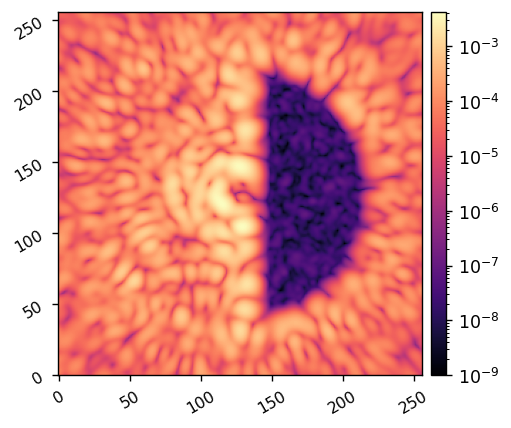

In [132]:
print(xp.mean(bbim[control_mask]))
imshow1(bbim, lognorm=True, vmin=1e-9)


In [123]:
utils.save_fits(f'../data/{today}_esc_fresnel_dh_commands_0.fits', xp.array(all_commands))

Saved data to:  ../data/20240930_esc_fresnel_dh_commands_0.fits
